# Graph Convolutional Network (GCN) for Multimodal Alzheimer's Classification

This notebook takes the fused multimodal feature matrix (clinical features +
512-dim ResNet18 MRI embeddings, 347 subjects × 520 features) and tests
whether representing subjects as nodes in a **similarity graph** — then
learning with a GCN — adds anything over flat tabular classifiers.

**Pipeline position:** Fusion dataset (`X_scaled`, `y`) → **KNN cosine-similarity graph** → 2-layer GCN → Evaluate → **Compare against CNN / RF / XGBoost baselines**

What this notebook does:
1. Builds a KNN graph over subjects using **cosine similarity** on the fused features, for **k = 5** and **k = 10**.
2. Constructs `edge_index`, node features, and labels for PyTorch Geometric.
3. Creates stratified train / validation / test masks.
4. Implements a 2-layer GCN: `GCNConv(520,128) → GCNConv(128,64) → Linear(64,3)`.
5. Trains with `CrossEntropyLoss`, Adam, and early stopping on validation Macro-F1.
6. Evaluates Accuracy, Precision, Recall, F1, Macro-F1, and Confusion Matrix.
7. Compares both k values against each other, and against your existing baselines:
   - Clinical Baseline ML = 0.840
   - MRI CNN: Macro-F1 = 0.594
   - Fusion Random Forest: Macro-F1 = 0.858
   - Fusion XGBoost: Macro-F1 = 0.858


## 1. Install Dependencies

In [1]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.11.0+cpu
CUDA available: False


In [2]:
# PyTorch Geometric (PyG)
import torch
TORCH_VERSION = torch.__version__.split("+")[0]
CUDA_VERSION = "cu" + torch.version.cuda.replace(".", "") if torch.cuda.is_available() else "cpu"

!pip install -q torch_geometric

print("Installed torch_geometric.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.8 MB/s eta 0:00:00
Installed torch_geometric.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 2. Load the Fused Multimodal Dataset

Loading the previous notebook

In [4]:
if "X_scaled" in globals() and "y" in globals():
    print("Using existing X_scaled / y from this session.")
    print("X_scaled shape:", X_scaled.shape)
    print("y shape:", y.shape)
else:
    print("X_scaled / y not found in this session — rebuilding from saved CSV.")

    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DIR = "/content/drive/MyDrive/alzheimer_project"
    final_df = pd.read_csv(f"{PROJECT_DIR}/final_multimodal_dataset.csv")

    from sklearn.preprocessing import StandardScaler

    emb_cols = [c for c in final_df.columns if c.startswith("emb_")]
    clinical_numeric_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
                              if c in final_df.columns]
    # NOTE: CDR intentionally excluded - it deterministically encodes the target.
    feature_cols = clinical_numeric_cols + (["Gender_enc"] if "Gender_enc" in final_df.columns else []) + emb_cols

    X = final_df[feature_cols].copy()
    y = final_df["target_enc"].copy()

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

    print("Rebuilt X_scaled shape:", X_scaled.shape)

print("\nClass distribution:")
print(y.value_counts().sort_index())

X_scaled / y not found in this session — rebuilding from saved CSV.
Mounted at /content/drive
Rebuilt X_scaled shape: (347, 520)

Class distribution:
target_enc
0     23
1    266
2     58
Name: count, dtype: int64


In [5]:

X_np = X_scaled.values.astype(np.float32)
y_np = y.values.astype(np.int64)

NUM_NODES = X_np.shape[0]
NUM_FEATURES = X_np.shape[1]
NUM_CLASSES = len(np.unique(y_np))

print(f"Nodes (subjects): {NUM_NODES}")
print(f"Node feature dim: {NUM_FEATURES}")
print(f"Classes: {NUM_CLASSES}")

Nodes (subjects): 347
Node feature dim: 520
Classes: 3


## 3. Subject Similarity Graph (KNN + Cosine Similarity)

Each subject becomes a **node**; an edge connects a subject to its
**k nearest neighbors** by **cosine similarity** over the fused 520-dim
feature vector. We make the graph **undirected** (symmetric) by adding the
reverse edges and de-duplicating.

We build this for both **k = 5** and **k = 10** since this is the key
hyperparameter for how much "neighborhood smoothing" the GCN does — too small
a k starves message passing, too large a k blurs class boundaries.

In [6]:
def build_knn_graph(X, k, metric="cosine"):
    '''
    Build a symmetric KNN graph and return:
      - edge_index: torch.LongTensor of shape [2, num_edges] (PyG format)
      - adjacency stats for inspection
    '''
    # connectivity mode -> binary adjacency (1 if neighbor, 0 otherwise)
    knn_graph = kneighbors_graph(
        X, n_neighbors=k, mode="connectivity", metric=metric, include_self=False
    )

    # Symmetrize: if i->j exists or j->i exists, keep the edge both ways
    knn_graph = knn_graph.maximum(knn_graph.T)

    coo = knn_graph.tocoo()
    edge_index = torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long)

    return edge_index, knn_graph


def graph_stats(edge_index, num_nodes, k):
    num_edges = edge_index.shape[1]
    degrees = np.zeros(num_nodes)
    for node in edge_index[0].numpy():
        degrees[node] += 1
    print(f"k = {k}")
    print(f"  Edges (directed, after symmetrizing): {num_edges}")
    print(f"  Avg degree: {degrees.mean():.2f}  (min={degrees.min():.0f}, max={degrees.max():.0f})")
    return degrees

In [7]:
edge_index_k5, adj_k5 = build_knn_graph(X_np, k=5, metric="cosine")
edge_index_k10, adj_k10 = build_knn_graph(X_np, k=10, metric="cosine")

degrees_k5 = graph_stats(edge_index_k5, NUM_NODES, k=5)
print()
degrees_k10 = graph_stats(edge_index_k10, NUM_NODES, k=10)

k = 5
  Edges (directed, after symmetrizing): 2520
  Avg degree: 7.26  (min=5, max=18)

k = 10
  Edges (directed, after symmetrizing): 4800
  Avg degree: 13.83  (min=10, max=28)


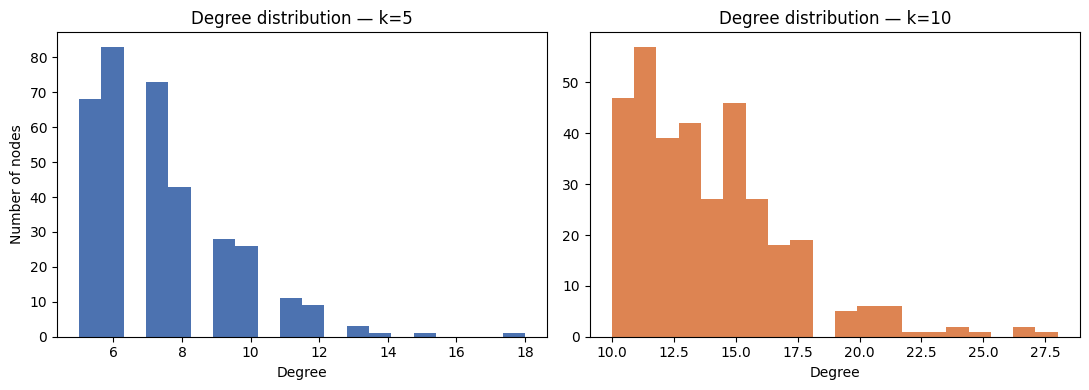

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(degrees_k5, bins=20, color="#4C72B0")
axes[0].set_title("Degree distribution — k=5")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Number of nodes")

axes[1].hist(degrees_k10, bins=20, color="#DD8452")
axes[1].set_title("Degree distribution — k=10")
axes[1].set_xlabel("Degree")

plt.tight_layout()
plt.show()

## 4. Node Features, Labels, and Train/Val/Test Masks

We split subjects **stratified by class** into 60% train / 20% validation /
20% test, then express the split as boolean node masks (the standard PyG
convention for node classification).

In [9]:
def make_masks(y_array, num_nodes, train_size=0.6, val_size=0.2, seed=SEED):
    indices = np.arange(num_nodes)

    train_idx, rest_idx = train_test_split(
        indices, train_size=train_size, stratify=y_array, random_state=seed
    )
    val_frac_of_rest = val_size / (1 - train_size)
    val_idx, test_idx = train_test_split(
        rest_idx, train_size=val_frac_of_rest,
        stratify=y_array[rest_idx], random_state=seed
    )

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    return train_mask, val_mask, test_mask


train_mask, val_mask, test_mask = make_masks(y_np, NUM_NODES)

print(f"Train nodes: {train_mask.sum().item()}")
print(f"Val nodes:   {val_mask.sum().item()}")
print(f"Test nodes:  {test_mask.sum().item()}")

print("\nClass balance check (train):")
print(pd.Series(y_np[train_mask.numpy()]).value_counts().sort_index())
print("\nClass balance check (test):")
print(pd.Series(y_np[test_mask.numpy()]).value_counts().sort_index())

Train nodes: 208
Val nodes:   69
Test nodes:  70

Class balance check (train):
0     14
1    159
2     35
Name: count, dtype: int64

Class balance check (test):
0     4
1    54
2    12
Name: count, dtype: int64


In [10]:
# Node features and labels shared across both k=5 and k=10 graphs
x = torch.tensor(X_np, dtype=torch.float)
y_t = torch.tensor(y_np, dtype=torch.long)

def make_data(edge_index, x, y_t, train_mask, val_mask, test_mask):
    data = Data(x=x, edge_index=edge_index, y=y_t)
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    return data

data_k5 = make_data(edge_index_k5, x, y_t, train_mask, val_mask, test_mask).to(device)
data_k10 = make_data(edge_index_k10, x, y_t, train_mask, val_mask, test_mask).to(device)

print(data_k5)
print(data_k10)

Data(x=[347, 520], edge_index=[2, 2520], y=[347], train_mask=[347], val_mask=[347], test_mask=[347])
Data(x=[347, 520], edge_index=[2, 4800], y=[347], train_mask=[347], val_mask=[347], test_mask=[347])


## 5. Define the GCN Model

A 2-layer GCN exactly per spec: `GCNConv(520→128) → GCNConv(128→64) → Linear(64→3)`,
with ReLU + Dropout between layers.

In [11]:
class GCN(nn.Module):
    def __init__(self, in_channels=520, hidden1=128, hidden2=64, num_classes=3, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)
        self.classifier = nn.Linear(hidden2, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        out = self.classifier(x)   # raw logits — CrossEntropyLoss applies softmax internally
        return out

## 6. Training Loop with Early Stopping

- Loss: `CrossEntropyLoss` (with class weights, since `Dementia` has only 23
  subjects total vs 266 `Non Demented`).
- Optimizer: Adam.
- Early stopping: monitor **validation Macro-F1**, stop if it doesn't improve
  for `patience` epochs, and restore the best-performing weights.

In [12]:
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(y_array, train_mask):
    train_labels = y_array[train_mask.cpu().numpy()]
    classes = np.unique(train_labels)
    weights = compute_class_weight("balanced", classes=classes, y=train_labels)
    return torch.tensor(weights, dtype=torch.float)


def train_gcn(data, num_classes=3, hidden1=128, hidden2=64,
              lr=0.01, weight_decay=5e-4, max_epochs=300, patience=20, verbose=True):

    model = GCN(in_channels=data.x.shape[1], hidden1=hidden1, hidden2=hidden2,
                num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    class_weights = get_class_weights(data.y.cpu().numpy(), data.train_mask).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_macro_f1 = -1
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}

    for epoch in range(1, max_epochs + 1):
        # --- Train step ---
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # --- Validation step ---
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()
            val_pred = out[data.val_mask].argmax(dim=1).cpu().numpy()
            val_true = data.y[data.val_mask].cpu().numpy()
            val_macro_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_macro_f1)

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | train_loss={loss.item():.4f} | "
                  f"val_loss={val_loss:.4f} | val_macro_f1={val_macro_f1:.4f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs).")
            break

    model.load_state_dict(best_state)
    print(f"Best validation Macro-F1: {best_val_macro_f1:.4f}")
    return model, history

## 7. Evaluation Helper

Computes Accuracy, Precision, Recall, F1 (weighted), Macro-F1, and the
confusion matrix on the test mask.

In [13]:
def evaluate_gcn(model, data, class_names, title=""):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
        true = data.y[data.test_mask].cpu().numpy()

    acc = accuracy_score(true, pred)
    prec = precision_score(true, pred, average="weighted", zero_division=0)
    rec = recall_score(true, pred, average="weighted", zero_division=0)
    f1 = f1_score(true, pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(true, pred, average="macro", zero_division=0)

    print(f"===== {title} — Test Set =====")
    print(classification_report(true, pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {title}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return {
        "Model": title,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Macro-F1": macro_f1,
    }


# Recover human-readable class names if the LabelEncoder is available from the fusion notebook,
# otherwise fall back to generic names ordered by encoded index.
if "le_target" in globals():
    class_names = list(le_target.classes_)
else:
    class_names = [f"class_{i}" for i in range(NUM_CLASSES)]

print("Class names (index order):", class_names)

Class names (index order): ['class_0', 'class_1', 'class_2']


## 8. Train & Evaluate — k = 5

In [14]:
print("Training GCN on k=5 graph...\n")
model_k5, history_k5 = train_gcn(data_k5, num_classes=NUM_CLASSES)

Training GCN on k=5 graph...

Epoch  20 | train_loss=0.1998 | val_loss=0.5257 | val_macro_f1=0.7475
Early stopping at epoch 31 (no val improvement for 20 epochs).
Best validation Macro-F1: 0.9134


===== GCN (k=5) — Test Set =====
              precision    recall  f1-score   support

     class_0       0.67      1.00      0.80         4
     class_1       1.00      0.94      0.97        54
     class_2       0.92      1.00      0.96        12

    accuracy                           0.96        70
   macro avg       0.86      0.98      0.91        70
weighted avg       0.97      0.96      0.96        70



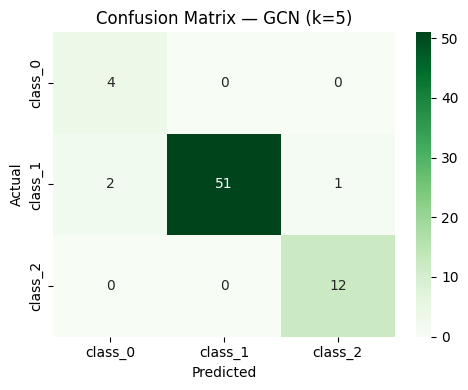

In [15]:
result_k5 = evaluate_gcn(model_k5, data_k5, class_names, title="GCN (k=5)")

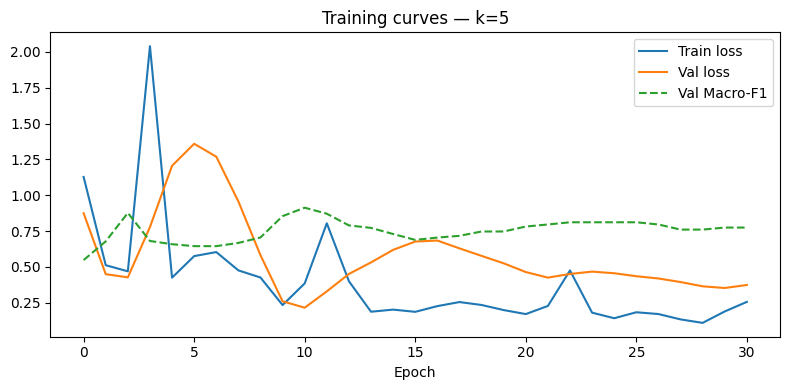

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history_k5["train_loss"], label="Train loss")
plt.plot(history_k5["val_loss"], label="Val loss")
plt.plot(history_k5["val_macro_f1"], label="Val Macro-F1", linestyle="--")
plt.title("Training curves — k=5")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Train & Evaluate — k = 10

In [17]:
print("Training GCN on k=10 graph...\n")
model_k10, history_k10 = train_gcn(data_k10, num_classes=NUM_CLASSES)

Training GCN on k=10 graph...

Epoch  20 | train_loss=0.2113 | val_loss=0.4856 | val_macro_f1=0.7277
Early stopping at epoch 36 (no val improvement for 20 epochs).
Best validation Macro-F1: 0.8502


===== GCN (k=10) — Test Set =====
              precision    recall  f1-score   support

     class_0       0.67      1.00      0.80         4
     class_1       1.00      0.94      0.97        54
     class_2       0.92      1.00      0.96        12

    accuracy                           0.96        70
   macro avg       0.86      0.98      0.91        70
weighted avg       0.97      0.96      0.96        70



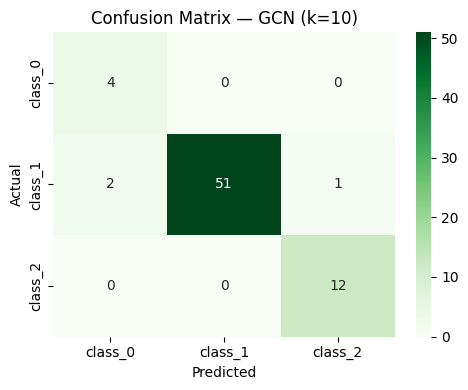

In [18]:
result_k10 = evaluate_gcn(model_k10, data_k10, class_names, title="GCN (k=10)")

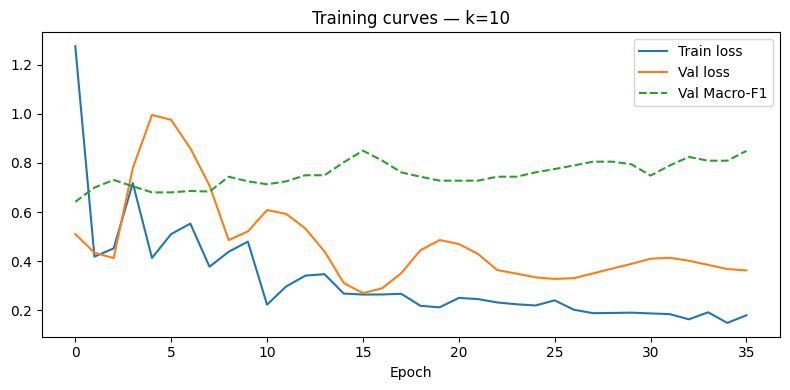

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(history_k10["train_loss"], label="Train loss")
plt.plot(history_k10["val_loss"], label="Val loss")
plt.plot(history_k10["val_macro_f1"], label="Val Macro-F1", linestyle="--")
plt.title("Training curves — k=10")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Compare k=5 vs k=10, and Against All Baselines

Bringing in your previously recorded baseline results:
- **MRI CNN** (image-only): Macro-F1 = 0.594
- **Fusion Random Forest**: Macro-F1 = 0.858
- **Fusion XGBoost**: Macro-F1 = 0.858
- **Clinical-only** (OASIS biomarkers/demographics, no MRI): Logistic Regression,
  Random Forest, XGBoost — from your separate `OASIS_Baseline_Models.ipynb` run.

> **Methodology caveat — read before drawing conclusions:** the clinical-only
> baselines were trained on a **different subject pool and a different task**
> than everything else in this table: 235 subjects (not 347) and **binary**
> classification (Demented vs Nondemented, not the 3-class Dementia / Very
> Mild / Non Demented target used by the fusion and GCN models). Binary
> Macro-F1 is also typically easier to score well on than 3-class Macro-F1,
> since there's only one decision boundary instead of two. Treat the
> clinical-only row as a **directional reference point** ("how far do
> demographics/cognitive scores alone get you without MRI"), not a strictly
> controlled comparison against the multimodal/GCN numbers.

In [20]:
baseline_results = [
    {"Model": "Clinical-only Logistic Regression", "Accuracy": 0.787, "Precision": np.nan,
     "Recall": np.nan, "F1-score": np.nan, "Macro-F1": 0.78},
    {"Model": "Clinical-only Random Forest", "Accuracy": 0.830, "Precision": np.nan,
     "Recall": np.nan, "F1-score": np.nan, "Macro-F1": 0.82},
    {"Model": "Clinical-only XGBoost", "Accuracy": 0.851, "Precision": np.nan,
     "Recall": np.nan, "F1-score": np.nan, "Macro-F1": 0.84},
    {"Model": "MRI CNN (image-only)", "Accuracy": np.nan, "Precision": np.nan,
     "Recall": np.nan, "F1-score": np.nan, "Macro-F1": 0.594},
    {"Model": "Fusion Random Forest", "Accuracy": 0.9286, "Precision": np.nan,
     "Recall": np.nan, "F1-score": np.nan, "Macro-F1": 0.858},
    {"Model": "Fusion XGBoost", "Accuracy": 0.9286, "Precision": np.nan,
     "Recall": np.nan, "F1-score": np.nan, "Macro-F1": 0.858},
]

all_results = pd.DataFrame(baseline_results + [result_k5, result_k10])
all_results = all_results.sort_values("Macro-F1", ascending=False).reset_index(drop=True)
all_results

,Model,Accuracy,Precision,Recall,F1-score,Macro-F1
0,GCN (k=5),0.957143,0.967766,0.957143,0.959673,0.910476
1,GCN (k=10),0.957143,0.967766,0.957143,0.959673,0.910476
2,Fusion Random Forest,0.928600,NaN,NaN,NaN,0.858000
3,Fusion XGBoost,0.928600,NaN,NaN,NaN,0.858000
4,Clinical-only XGBoost,0.851000,NaN,NaN,NaN,0.840000
5,Clinical-only Random Forest,0.830000,NaN,NaN,NaN,0.820000
6,Clinical-only Logistic Regression,0.787000,NaN,NaN,NaN,0.780000
7,MRI CNN (image-only),NaN,NaN,NaN,NaN,0.594000


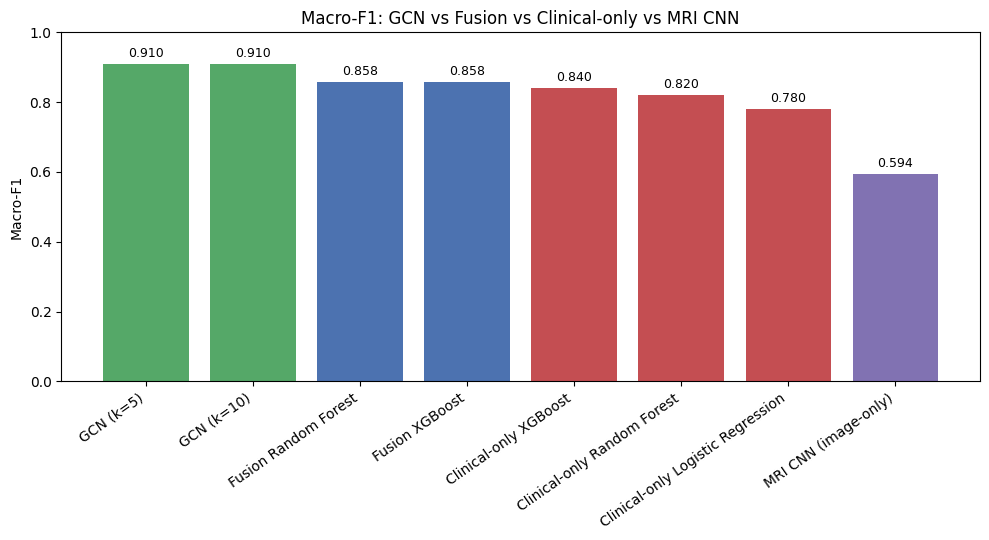

In [21]:
plt.figure(figsize=(10, 5.5))


def bar_color(model_name):
    if "GCN" in model_name:
        return "#55A868"
    elif "Clinical-only" in model_name:
        return "#C44E52"
    elif "Fusion" in model_name:
        return "#4C72B0"
    else:
        return "#8172B2"


bars = plt.bar(all_results["Model"], all_results["Macro-F1"],
               color=[bar_color(m) for m in all_results["Model"]])
plt.ylabel("Macro-F1")
plt.title("Macro-F1: GCN vs Fusion vs Clinical-only vs MRI CNN")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
for bar, val in zip(bars, all_results["Macro-F1"]):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
              ha="center", fontsize=9)
plt.tight_layout()
plt.show()